In [37]:
"""
Momentum Strategy Notebook
==========================

Implements a long-short momentum strategy using:
- 3-month momentum signals
- top 20 percent long, bottom 20 percent short
- monthly rebalancing
- Team 2's backtester for evaluation
"""

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import sys
import os

plt.style.use("seaborn-v0_8")

# ------------------------------------------------------------
# Add project root to sys.path (so utils/* can be imported)
# ------------------------------------------------------------
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../"))
sys.path.append(project_root)

# Import Ranking class
from utils.ranking import Ranking


In [38]:
"""
Data Loading
============

Downloads adjusted close prices for 30 liquid US equities.
"""

tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "TSLA", "JPM", "BAC", "XOM",
    "CVX", "V", "MA", "HD", "PG",
    "KO", "PEP", "DIS", "NFLX", "INTC",
    "CSCO", "ORCL", "PFE", "MRK", "WMT",
    "UNH", "T", "VZ", "ABBV", "ADBE"
]

start_date = "2015-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
data = data.dropna(axis=1, how="all")

display(data.tail())


[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,ABBV,ADBE,AMZN,BAC,CSCO,CVX,DIS,GOOGL,HD,...,PEP,PFE,PG,T,TSLA,UNH,V,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,257.037476,173.918823,447.940002,229.050003,43.600803,58.345387,139.002747,112.082031,195.472717,389.003815,...,148.375351,24.935757,164.591461,21.966003,462.279999,497.256958,318.388580,37.236317,91.988403,103.530914
2024-12-26,257.853790,173.145828,450.160004,227.050003,43.767818,58.472118,139.138031,112.072083,194.964386,388.021851,...,148.016068,24.767904,165.780075,21.975576,454.130005,502.218719,318.646790,37.386009,92.097588,103.618484
2024-12-27,254.439224,171.996017,446.480011,223.750000,43.561504,58.111423,139.157364,111.076332,192.133606,385.782867,...,148.453018,24.823854,165.166290,21.879862,431.660004,501.078949,316.412628,37.348587,90.976028,103.608757
2024-12-30,251.064484,170.247192,445.799988,221.300003,43.139057,57.701984,138.258636,110.329514,190.618546,382.414642,...,147.316986,24.637348,162.789078,21.640581,417.410004,498.927246,313.086273,37.049198,89.894150,102.908173
2024-12-31,249.292511,171.696518,444.679993,219.389999,43.178352,57.711731,139.969116,110.877174,188.684860,381.982574,...,147.647110,24.739925,163.334686,21.793722,403.839996,497.021149,313.811127,37.414078,89.675797,104.669357


In [39]:
"""
Momentum Window Construction
============================

- Compute daily returns
- Compute month-end timestamps
- Compute 3-month momentum (approx. 63 trading days)
"""

daily_returns = data.pct_change().dropna()
month_ends = data.resample("ME").last().index
monthly_prices = data.resample("ME").last()

momentum_3m = monthly_prices.pct_change(periods=3)
display(momentum_3m.tail())


Ticker,AAPL,ABBV,ADBE,AMZN,BAC,CSCO,CVX,DIS,GOOGL,HD,...,PEP,PFE,PG,T,TSLA,UNH,V,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,0.192536,0.228686,0.291505,0.011675,0.025202,0.096193,-0.078214,-0.126196,-0.051782,0.107111,...,0.007768,0.026497,0.048813,0.108600,0.202325,0.196487,0.016385,0.031926,0.177770,0.013897
2024-09-30,0.107538,0.161929,-0.067970,-0.035809,0.004242,0.129782,-0.047959,-0.026752,-0.088278,0.184235,...,0.038895,0.048907,0.056522,0.168509,0.322165,0.152168,0.049649,0.106813,0.195985,0.026440
2024-10-31,0.018423,0.108882,-0.133364,-0.003102,0.044223,0.139083,-0.062220,0.026790,-0.001183,0.076004,...,-0.030841,-0.073346,0.033536,0.185943,0.076615,-0.016763,0.093203,0.055964,0.197313,-0.007335
2024-11-30,0.037516,-0.060716,-0.101809,0.164650,0.173491,0.180501,0.105656,0.299735,0.035464,0.170664,...,-0.047347,-0.082485,0.051148,0.178762,0.612069,0.037553,0.142233,0.077841,0.197721,0.008388
2024-12-31,0.075946,-0.092976,-0.141180,0.177427,0.113772,0.120865,-0.006468,0.162734,0.142701,-0.034950,...,-0.098178,-0.069037,-0.026353,0.048289,0.543554,-0.131490,0.151631,-0.095652,0.121364,-0.074783


In [40]:
"""
Signal Construction
===================

Select top 20 percent (long) and bottom 20 percent (short)
based on 3-month momentum. Equal-weighted within each side.
"""

def build_ls_weights(momentum_row, long_quantile=0.8, short_quantile=0.2):
    """
    Construct long-short weights from cross-sectional momentum.

    Parameters
    ----------
    momentum_row : pd.Series
        Momentum scores at a specific date for multiple assets.
    long_quantile : float
        Quantile threshold for long selections.
    short_quantile : float
        Quantile threshold for short selections.

    Returns
    -------
    pd.Series
        Weight vector with +weights for long assets and -weights for shorts.
    """
    mom = momentum_row.dropna()
    if mom.empty:
        return pd.Series(dtype=float)

    long_thresh = mom.quantile(long_quantile)
    short_thresh = mom.quantile(short_quantile)

    long_assets = mom[mom >= long_thresh].index
    short_assets = mom[mom <= short_thresh].index

    n_long = len(long_assets)
    n_short = len(short_assets)
    if n_long == 0 or n_short == 0:
        return pd.Series(dtype=float)

    w_long = 1.0 / n_long
    w_short = -1.0 / n_short

    weights = pd.Series(0.0, index=mom.index)
    weights.loc[long_assets] = w_long
    weights.loc[short_assets] = w_short

    return weights


weights_monthly = pd.DataFrame(index=month_ends, columns=data.columns, dtype=float)

for dt in month_ends:
    if dt in momentum_3m.index:
        w = build_ls_weights(momentum_3m.loc[dt], 0.8, 0.2)
        weights_monthly.loc[dt, w.index] = w

display(weights_monthly.head())


,AAPL,ABBV,ADBE,AMZN,BAC,CSCO,CVX,DIS,GOOGL,HD,...,PEP,PFE,PG,T,TSLA,UNH,V,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,0.0,0.000000,0.0,0.166667,0.0,0.0,0.000000,0.166667,0.000000,0.0,...,0.0,0.0,-0.166667,0.0,0.000000,0.0,0.0,0.0,-0.166667,-0.166667
2015-05-31,0.0,0.166667,0.0,0.166667,0.0,0.0,-0.166667,0.000000,-0.166667,0.0,...,0.0,0.0,-0.166667,0.0,0.166667,0.0,0.0,0.0,-0.166667,-0.166667


In [41]:
"""
Daily Weight Expansion
======================

Expand monthly weights into daily weights by:
- applying them on the first trading day after month-end
- forward-filling until next rebalance
"""

weights_daily = pd.DataFrame(index=daily_returns.index, columns=daily_returns.columns, dtype=float)

for me in month_ends:
    valid_days = daily_returns.loc[daily_returns.index > me].index
    if len(valid_days) == 0:
        continue
    start = valid_days[0]

    if me in weights_monthly.index:
        w = weights_monthly.loc[me].fillna(0.0)
        next_me = next((d for d in month_ends if d > me), None)

        if next_me is not None:
            mask = (weights_daily.index >= start) & (weights_daily.index <= next_me)
        else:
            mask = weights_daily.index >= start

        weights_daily.loc[mask, :] = w.values

weights_daily = weights_daily.fillna(method="ffill").fillna(0.0)

display(weights_daily.head())


/tmp/ipykernel_467884/77297076.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weights_daily = weights_daily.fillna(method="ffill").fillna(0.0)


Ticker,AAPL,ABBV,ADBE,AMZN,BAC,CSCO,CVX,DIS,GOOGL,HD,...,PEP,PFE,PG,T,TSLA,UNH,V,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
"""
Portfolio Returns
=================

Compute total long-short portfolio returns:
    r_p = sum( w_i * r_i )
"""

common_idx = daily_returns.index.intersection(weights_daily.index)
daily_returns_aligned = daily_returns.loc[common_idx]
weights_daily_aligned = weights_daily.loc[common_idx]

portfolio_daily_returns = (weights_daily_aligned * daily_returns_aligned).sum(axis=1)

display(portfolio_daily_returns.head())


Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
2015-01-09    0.0
dtype: float64

In [43]:
"""
Long/Short Decomposition
========================

Team 2's backtester requires:
- long_returns : pd.Series
- short_returns : pd.Series
"""

# Positive weights only (long leg)
long_mask = weights_daily_aligned.clip(lower=0)

# Negative weights only, converted to positive (short leg)
short_mask = -weights_daily_aligned.clip(upper=0)

long_returns = (long_mask * daily_returns_aligned).sum(axis=1)
short_returns = (short_mask * daily_returns_aligned).sum(axis=1)

print("Long returns sample:")
display(long_returns.head())

print("Short returns sample:")
display(short_returns.head())


Long returns sample:


Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
2015-01-09    0.0
dtype: float64

Short returns sample:


Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
2015-01-09    0.0
dtype: float64

Performance Metrics:
{'Total Return': np.float64(2.1682166788001), 'Annualized Return': np.float64(0.12248631047739544), 'Annualized Volatility': np.float64(0.23009456230233438), 'Sharpe Ratio': np.float64(0.4454095283778711), 'Max Drawdown': np.float64(-0.31453609215798367), 'Win Rate': np.float64(0.5165009940357853), 'Avg Win': np.float64(0.010390432820669936), 'Avg Loss': np.float64(-0.010642497573160728), 'Best Day': np.float64(0.08173645861196734), 'Worst Day': np.float64(-0.09189756758911366), 'Total Days': 2515}


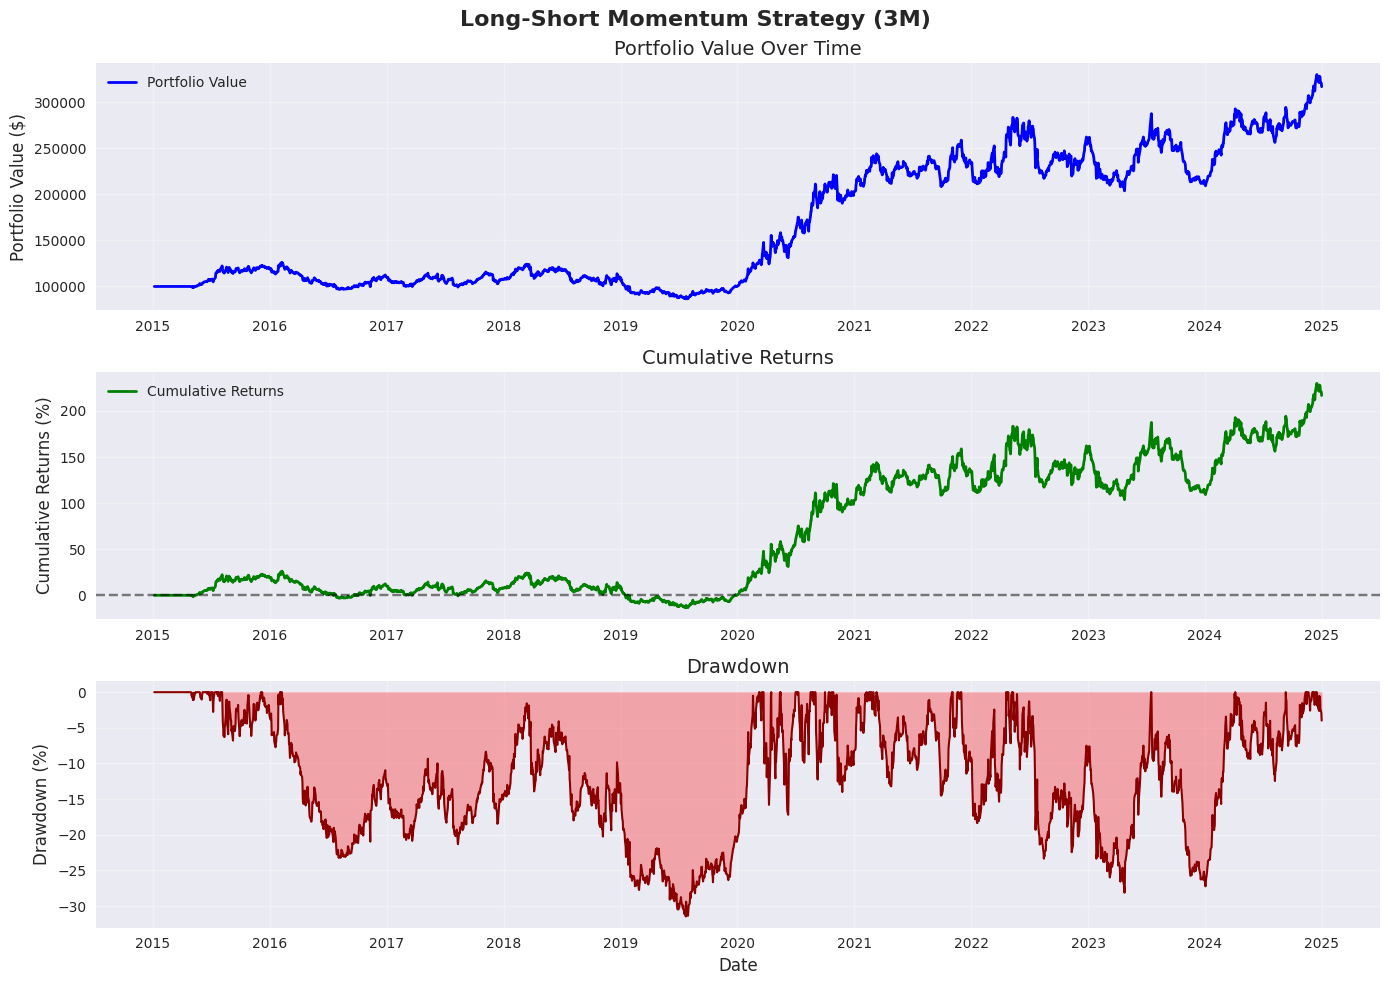

In [44]:
"""
Backtest Evaluation
===================

Run Team 2’s backtester, print summary stats, and generate plots.
"""

from utils import backtest, summary_stats, plot_backtest_results

initial_capital = 100_000

results = backtest(
    long_returns=long_returns,
    short_returns=short_returns,
    initial_capital=initial_capital,
    leverage=1.0
)

stats = summary_stats(results["returns"])
print("Performance Metrics:")
print(stats)

fig = plot_backtest_results(results, title="Long-Short Momentum Strategy (3M)")
plt.show()
